In [140]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import (
    Any,
    List, 
    Union, 
    Optional, 
    Callable, 
    Sequence, 
    Literal
)
from transformers import (
    EsmForMaskedLM, 
    EsmConfig,
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch.distributions.categorical import Categorical
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt
import matplotlib as mpl
import plotly.express as px
import plotly.graph_objects as go

from jaxtyping import Bool, Float, Int

from plotly_utils import (
    imshow,
    line
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile
from dataclasses import dataclass

from jumprelu_SAE import ToySAEConfig, JumpReLUToySAE, cycle, linear_lr

In [4]:
TOK_DIR = "./covfit_stuff/Tokenizer"
CONF_DIR = "./covfit_stuff/Config"
TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt"
FOLD_ID = 0
N_TARGETS = 1565
MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt"

In [5]:
# MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
# FOLD_IDS_TO_USE = [0]
# TARGET_FOLD_ID = 0
# OUTPUT_PREFIX = "inference_results"

model_name = "facebook/esm2_t33_650M_UR50D"
device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

# Load Model

In [6]:
def get_model(
    TOK_DIR = "./covfit_stuff/Tokenizer",
    CONF_DIR = "./covfit_stuff/Config",
    TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt",
    FOLD_ID = 0,
    N_TARGETS = 1565,
    MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt",
    device=device
):
    esm_config = EsmConfig.from_pretrained(CONF_DIR)
    model = EsmForRegression(esm_config, N_TARGETS).to(device)

    lora_config = LoraConfig(
        task_type="SEQ_CLS",
        r=8,
        lora_alpha=16,
        target_modules=["key", "query", "value","dense"],
        lora_dropout=0.05,
        bias="lora_only",
        modules_to_save=["regressor"]
    )
    esm_fine_tuned = get_peft_model(model, lora_config)
    print("loaded LORA model")
    state_dict = torch.load(MODEL_PATH, map_location=device)
    
    # keys_to_remove = []
    # for key in state_dict.keys():
    #     if 'contact_head' in key:
    #         keys_to_remove.append(key)
    
    # for key in keys_to_remove:
    #     del state_dict[key]

    wrong_keys = [key for key in state_dict.keys() if key not in esm_fine_tuned.state_dict().keys()]
    key_list = list(state_dict.keys())
    for key in key_list:
        if key in wrong_keys:
            correct_key = key.rsplit('.',1)[0]+'.base_layer.'+key.rsplit('.',1)[1]
            state_dict[correct_key] = state_dict.pop(key)

    del state_dict["base_model.model.esm.embeddings.position_embeddings.base_layer.weight"]
    
    esm_fine_tuned.load_state_dict(state_dict)
    print("Loaded state dict!")
    esm_fine_tuned = esm_fine_tuned.merge_and_unload()
    esm_fine_tuned.eval()
    print("merged LORA weights")
    esm_fine_tuned.esm.embeddings.token_dropout = False

    return esm_fine_tuned

In [7]:
esm_fine_tuned = get_model()

loaded LORA model
Loaded state dict!
merged LORA weights


In [8]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [9]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name
REPO_ID = esm_config.model_name
original_task_id_infos = torch.load("./covfit_stuff/task_id_dict.pt", map_location=device)

In [10]:
tokenizer_config = {}
special_tokens_map_file = "./covfit_stuff/Tokenizer/special_tokens_map.json"
tokenizer_config["vocab_file"] = "./covfit_stuff/Tokenizer/vocab.txt"
tokenizer_config["model_max_length"] = CONTEXT_LEN

with open("./covfit_stuff/Tokenizer/special_tokens_map.json", "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [11]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

In [12]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


# Data 

In [13]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [14]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [15]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [16]:
"""
uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]
    
    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences 

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences 
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# L455F mutation 
orig_idx = [i for i,x in enumerate(all_uniq_seqs) if x[454] == "L"][:100] # low fitness
new_idx = [i + len(all_uniq_seqs) for i in range(100)] # high fitness

orig_seqs = [all_uniq_seqs[i] for i in orig_idx]
new_seqs = [all_uniq_seqs[i][:454] + "F" + all_uniq_seqs[i][455:] for i in orig_idx]

orig_toks = tokenizer(orig_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
new_toks = tokenizer(new_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)

In [17]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [18]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [19]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [20]:
logit_id = original_task_id_infos["fitness_USA"]
dim_mlp = esm_fine_tuned.regressor[0].weight.size(0)
# logit_id = original_task_id_infos["fitness_South Korea"]

In [21]:
# SAE dataset
##########################################
# adding data with FLip mutation (L455F)
synthetic_data = [x for x in all_uniq_seqs if x[454] == "L"]
synthetic_data = [x[:454] + "F" + x[455:] for x in synthetic_data]

train_sae_seqs = tokenizer([*all_uniq_seqs, *synthetic_data], return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs) + len(synthetic_data)}")
print(train_sae_seqs.shape)

print(torch.equal(orig_toks, train_sae_seqs[orig_idx]))
print(torch.equal(new_toks, train_sae_seqs[new_idx]))

sars_cov_2_spike
Number unique sequences: 7978
torch.Size([7978, 1024])
True
True


In [22]:
# Prepare training data for SAE
##########################################
batch_len = 50
num_data = train_sae_seqs.size(0)

# data for SAE
sae_data_activations = torch.zeros(num_data, dim_mlp).to(device)

for i in tqdm(range(0,num_data,batch_len)):
    esm_output = hooked_esm(train_sae_seqs[i:i+batch_len])
    
    batch_output = get_logit_hooked(esm_output, list(range(d_out_vocab)))
    # apply linear and ReLU() of esm_regressor to get activations
    batch_activations = esm_fine_tuned.regressor[1](esm_fine_tuned.regressor[0](esm_output[:,0,:]))
    
    sae_data_activations[i:i+batch_len] = batch_activations
    torch.cuda.empty_cache()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 160/160 [15:55<00:00,  5.97s/it]


In [23]:
torch.autograd.grad_mode.set_grad_enabled(True)
MAGNIFICATION_SIZE = 1e3 # multiply data by constant factor to ensure stable training

In [24]:
sae_train_dataset = torch.utils.data.DataLoader(sae_data_activations * MAGNIFICATION_SIZE, batch_size=200, shuffle=False)
data = cycle(sae_train_dataset)
def generate_batch() -> Float[Tensor, "batch inst d_in"]:
    """
    Generates a batch of hidden activations from our model.
    """
    return einops.repeat(next(data), "batch d_in -> batch inst d_in", inst=1)

# (Jump-ReLU) SAE
### SAE is used in dictionary learning -- Given our dataset $\{x_n\}_{n=1}^N$, we learn an encoder $f:X^m\to X^M$ and decoder $W = [d_1,... d_D]\, s.t.\, x_i\approx\sum_{j=1}^M f_j(x_i) * d_j$
### These $d_j$ represent features in our original space (of dimension $dim_{MLP}$) and by taking the dot product of these vectors with our $W_U[:,\text{logit\_id}]$, we can figure out which features the model believes are correlated with high and low fitness respectively. 
### Then, we can analyze the sequences in our dataset that have the largest activations for the coefficient of these features (Find the $x_i$ which causes $f_j(x_i)$ to have the largest values) and use that to figure out what these features can refer to
### Effectively, what this enables us to do is make a (somewhat justified) claim about what regressor MLP layer is doing when it's trying to predict fitness

## Training SAE (multiplying dataset by constant so that bias does not take over)

In [25]:
d_in = dim_mlp
d_sae = d_in * 32
# print(d_sae)
# print(d_in)
# print(sae_data_activations.shape)

In [26]:
jumprelu_sae = JumpReLUToySAE(
    cfg=ToySAEConfig(
        n_inst=1, # used to train multiple models at once -- unnecessary at this time, so n_inst=1
        d_in=d_in, 
        d_sae=d_sae, 
        tied_weights=True, 
        sparsity_coeff=0.1,
    ),
    # pre_set_bias=sae_data_activations.mean(dim=0)
    pre_set_bias=None
)

In [27]:
# # Train SAE
# ###########################################
# jumprelu_data_log = jumprelu_sae.optimize(
#     steps=4_500,
#     resample_method="advanced",
#     lr_scale=linear_lr,
#     lr=1e-3,
#     generate_batch=generate_batch
# )  # batch_size=4096?

# Saving/Loading pre-trained SAE 

In [28]:
# # saving
# with open("./covfit_stuff/SAE/jumprelu_sae_save_03_05_26.pkl", "wb") as file:
#     pickle.dump((jumprelu_sae, jumprelu_data_log), file)

# loading
with open("./covfit_stuff/SAE/jumprelu_sae_save_03_05_26.pkl", "rb") as file:
    jumprelu_sae, jumprelu_data_log = pickle.load(file)

# Visualizing SAE training

In [29]:
print(jumprelu_data_log[0].keys())

dict_keys(['steps', 'frac_active', 'loss', 'h', 'h_r', 'b_dec', 'b_enc', 'W_enc', 'log_theta', 'L_reconstruction', 'L_sparsity'])


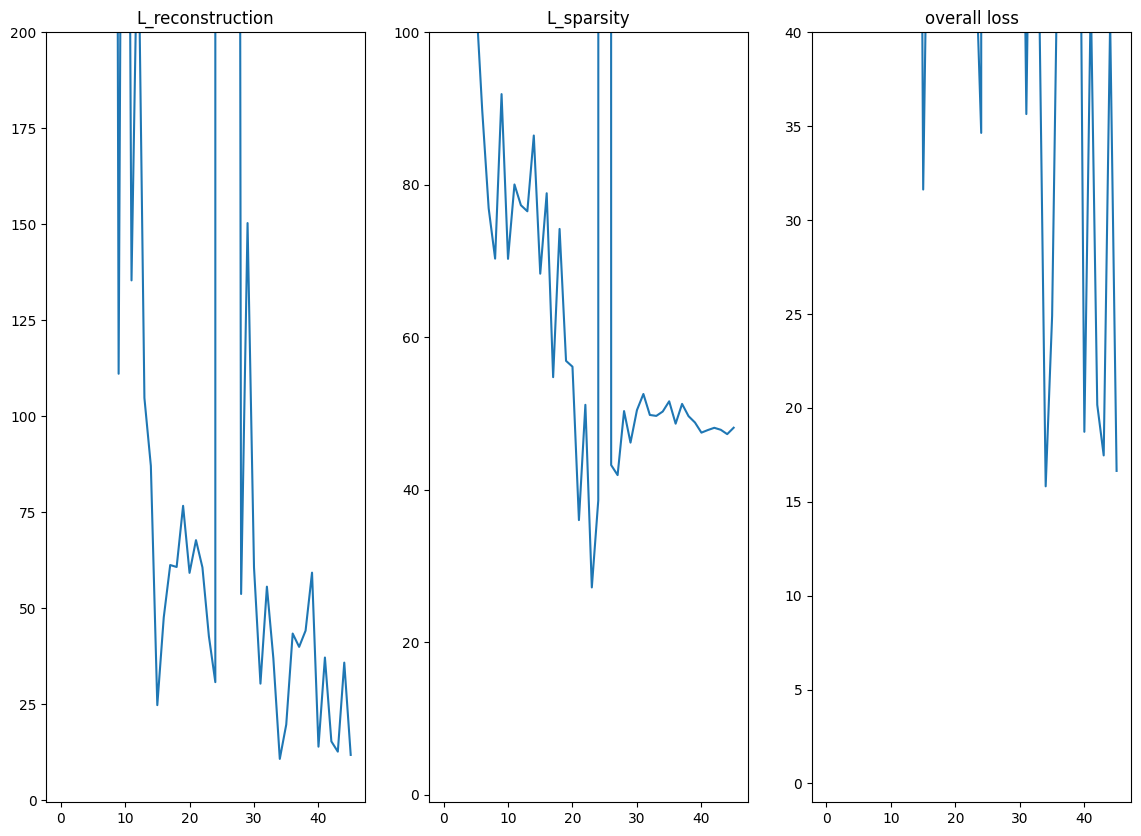

In [32]:
data_rank = None
# data_rank = torch.linalg.matrix_rank(sae_data_activations).item()

fig, ax = plt.subplots(1,3,figsize=(14,10))
ax[0].plot(list(range(len(jumprelu_data_log))), [d["L_reconstruction"].mean(dim=0) for d in jumprelu_data_log])
ax[0].set_ylim([-0.5,200])
ax[0].set_title("L_reconstruction")

ax[1].plot(list(range(len(jumprelu_data_log))), [d["L_sparsity"].mean(dim=0) for d in jumprelu_data_log])
if data_rank:
    ax[1].plot([0,len(jumprelu_data_log)], [data_rank, data_rank], linestyle="dashed", label="actual rank of data", color="black")
    ax[1].legend()
ax[1].set_ylim([-1,100])
ax[1].set_title("L_sparsity")

ax[2].plot(list(range(len(jumprelu_data_log))), [d["loss"].mean(dim=0) for d in jumprelu_data_log])
ax[2].set_ylim([-1,40])
ax[2].set_title("overall loss")
plt.show()

In [33]:
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

## which SAE features make up the difference

In [34]:
print(sae_data_activations.shape)

torch.Size([7978, 256])


In [35]:
print(sae_data_activations.shape)

torch.Size([7978, 256])


In [36]:
# mut_reg_acts = esm_fine_tuned.regressor[1](esm_fine_tuned.regressor[0](hooked_esm(new_toks)[:,0,:]))
# orig_reg_acts = esm_fine_tuned.regressor[1](esm_fine_tuned.regressor[0](hooked_esm(orig_toks)[:,0,:]))
mut_reg_acts = sae_data_activations[new_idx]
orig_reg_acts = sae_data_activations[orig_idx]
torch.cuda.empty_cache()

In [37]:
_, _, mut_sae_coefs, mut_recon = jumprelu_sae.forward(mut_reg_acts[:, None, :] * MAGNIFICATION_SIZE) #[batch, 1, d_sae], 1 for the n_inst which will be removed
_, _, orig_sae_coefs, orig_recon = jumprelu_sae.forward(orig_reg_acts[:, None, :] * MAGNIFICATION_SIZE) #[batch, 1, d_sae], 1 for the n_inst which will be removed

mut_sae_coefs = mut_sae_coefs.squeeze()
orig_sae_coefs = orig_sae_coefs.squeeze()

mut_recon = mut_recon.squeeze()
orig_recon = orig_recon.squeeze()

In [38]:
diff_coefs = (mut_sae_coefs - orig_sae_coefs).abs().mean(dim=0)
topk_feat_vals, topk_feat_inds = diff_coefs.topk(k=40, largest=True)

In [39]:
_, _, sae_coefs_all_data, _ = jumprelu_sae.forward(sae_data_activations[:,None,:] * MAGNIFICATION_SIZE)
sae_coefs_all_data = sae_coefs_all_data.squeeze()
torch.cuda.empty_cache()

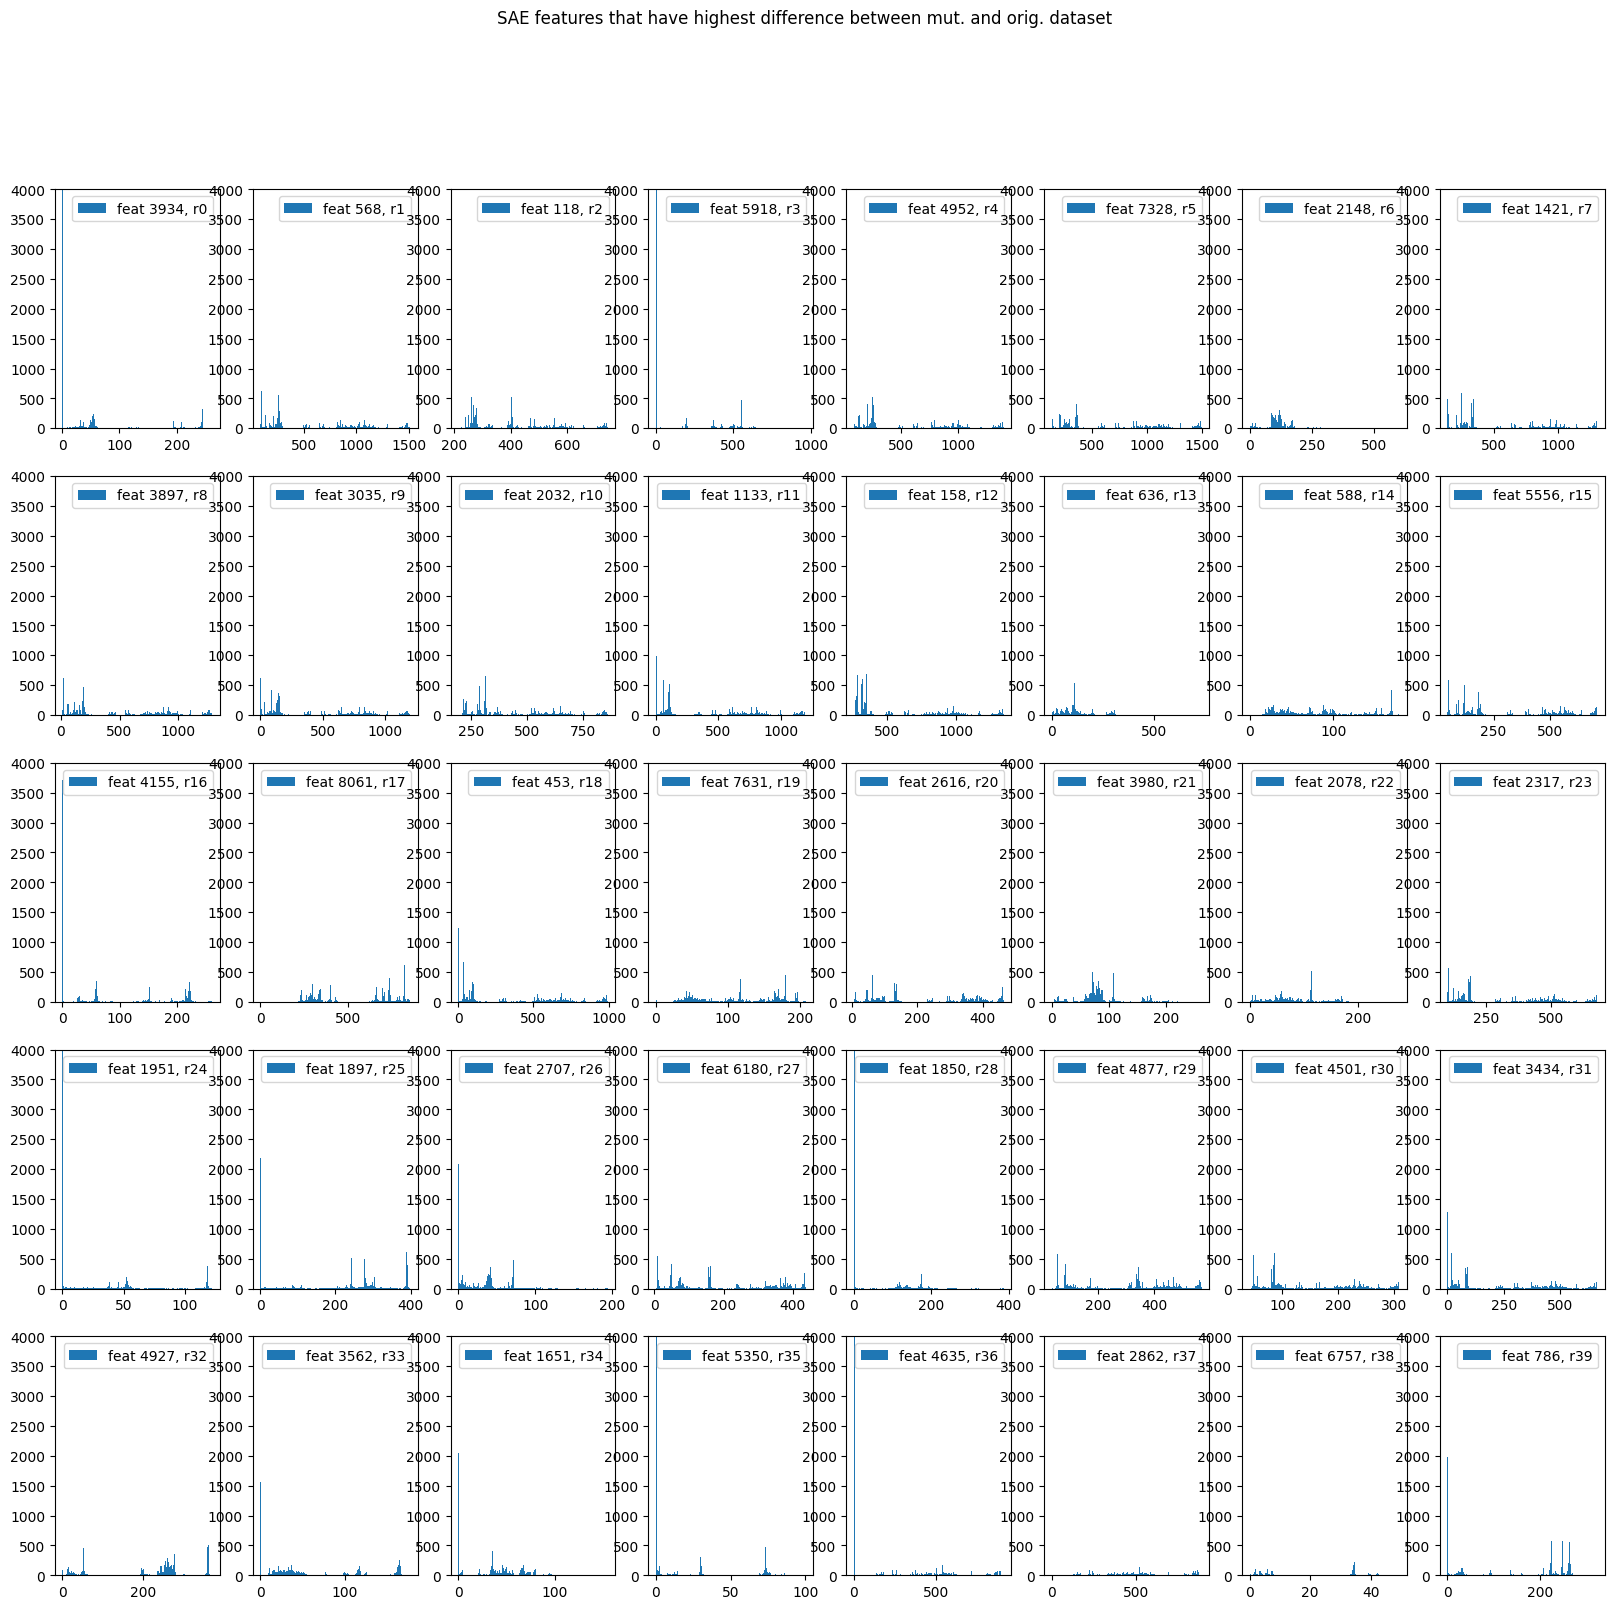

In [40]:
rows = 5
cols = 8
fig, ax = plt.subplots(rows,cols,figsize=(20,18))
for i in range(rows):
    for j in range(cols):
        feat_ind = i * cols + j
        ax[i,j].hist(sae_coefs_all_data[:, topk_feat_inds[feat_ind]].cpu().numpy(), label=f"feat {topk_feat_inds[feat_ind]}, r{feat_ind}", bins=200)
        ax[i,j].set_ylim([0,4000])
        ax[i,j].legend()
fig.suptitle("SAE features that have highest difference between mut. and orig. dataset")
plt.show()

# Visualizing features scores ($d_j$ dot product with $W_U[:,\text{logit\_id}]$ for each j)
### What you'll see is that most features are not correlated with fitness at all but there are a few key features that have high(-er) cosine score with the fitness decoding column

# Visualizing key features correlated with fitness (features with top .05% and bottom 10% cosine similarity with fitness decoding column respectively)

# Analysis with normalized columns

In [41]:
normed_cols = jumprelu_sae.W_dec[0] / jumprelu_sae.W_dec[0].norm(dim=1)[:,None]

logit_id_decoding_row = esm_fine_tuned.regressor[3].weight[logit_id,:]
logit_id_decoding_row = logit_id_decoding_row / logit_id_decoding_row.norm()

sae_feature_scores = einops.einsum(normed_cols, logit_id_decoding_row, "d_sae d_mlp, d_mlp -> d_sae").detach().cpu().numpy()

In [42]:
sae_feature_score_sorted_indices = np.argsort(sae_feature_scores)[::-1]
sae_quantile_95 = np.quantile(sae_feature_scores, 0.99)
sae_quantile_05 = np.quantile(sae_feature_scores, 0.1)
high_fit_sae_feats = sae_feature_score_sorted_indices[np.argwhere(sae_feature_scores[sae_feature_score_sorted_indices] > sae_quantile_95)[:,0]]
low_fit_sae_feats = sae_feature_score_sorted_indices[np.argwhere(sae_feature_scores[sae_feature_score_sorted_indices] < sae_quantile_05)[:,0]]
# topk_sae = 10
# sae_quantile_95 = sae_feature_scores[sae_feature_score_sorted_indices[topk_sae]]
# sae_quantile_05 = sae_feature_scores[sae_feature_score_sorted_indices[-topk_sae]]
# high_fit_sae_feats = sae_feature_score_sorted_indices[:topk_sae]
# low_fit_sae_feats = sae_feature_score_sorted_indices[-topk_sae:]

In [43]:
disp_topk_feat_inds = topk_feat_inds.cpu().numpy()
disp_top_feat_inds_argsort_idx = np.argsort(sae_feature_scores[disp_topk_feat_inds])[::-1]

disp_topk_map = {x:i for i,x in enumerate(sae_feature_score_sorted_indices)}
disp_top_feat_rev_inds = [disp_topk_map[x] for x in disp_topk_feat_inds]

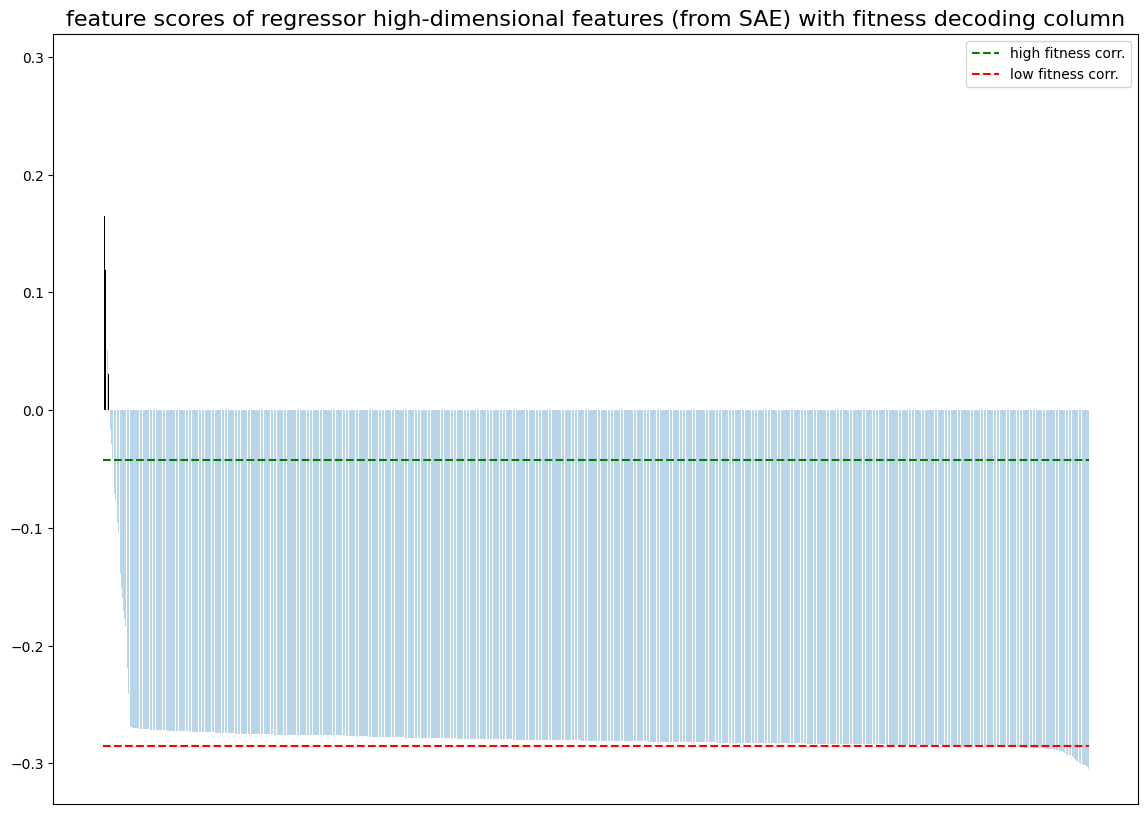

In [44]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.set_title("feature scores of regressor high-dimensional features (from SAE) with fitness decoding column", fontsize=16)
ax.bar(list(range(d_sae)), sae_feature_scores[sae_feature_score_sorted_indices], alpha=0.3)
ax.bar(disp_top_feat_rev_inds, sae_feature_scores[disp_topk_feat_inds], color="black")
ax.plot([0,d_sae], [sae_quantile_95, sae_quantile_95], color="green", label="high fitness corr.", linestyle="dashed")
ax.plot([0,d_sae], [sae_quantile_05, sae_quantile_05], color="red", label="low fitness corr.", linestyle="dashed")
ax.set_xticks([])
ax.legend()
plt.show()

0:	 47.794921875
3:	 42.37522506713867
6:	 40.36407470703125
13:	 27.49976921081543
16:	 22.59988784790039
18:	 20.77021026611328
22:	 16.127233505249023
24:	 15.993624687194824
25:	 15.81025505065918
26:	 15.418848991394043
28:	 13.145278930664062
31:	 12.15045166015625
33:	 11.650266647338867
34:	 11.10927677154541
35:	 10.556406021118164
36:	 10.191737174987793
39:	 7.153660774230957


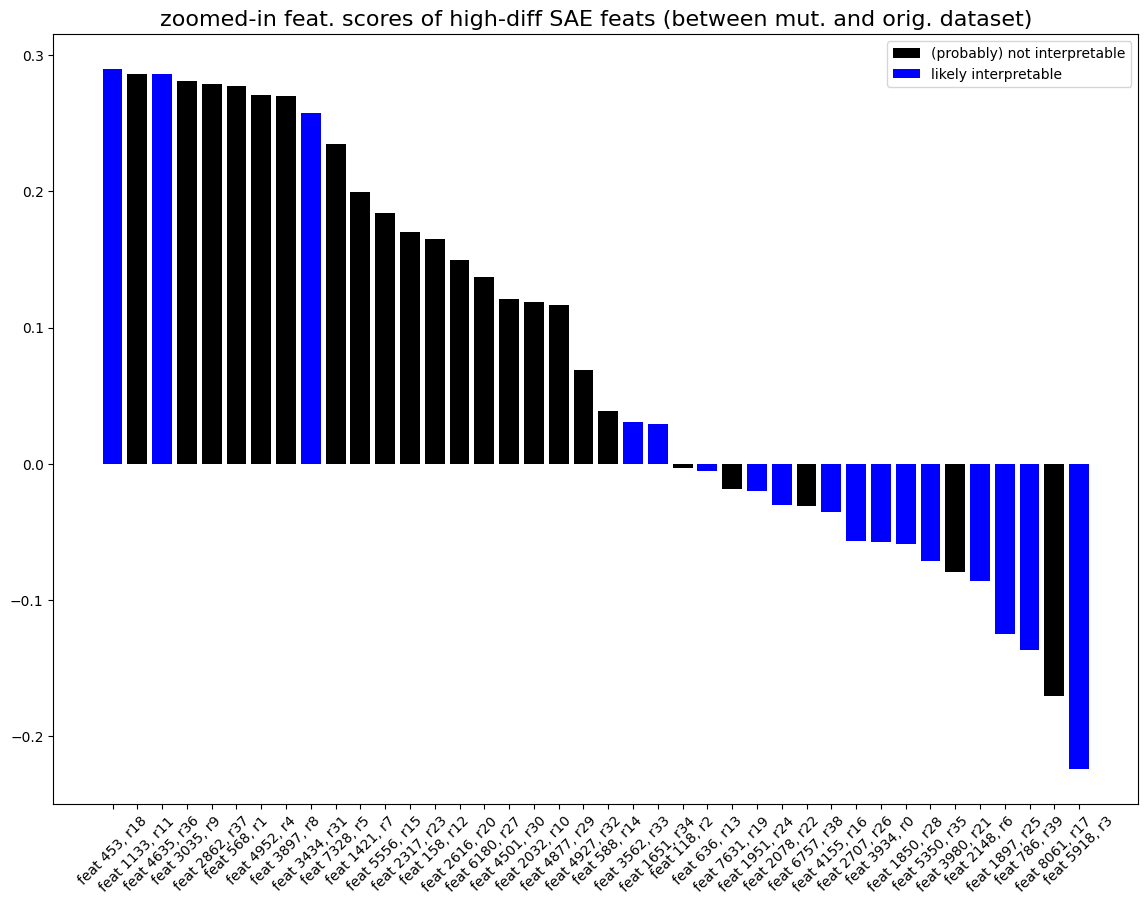

In [45]:
high_interp_feats = [0,3,6,13,16,18,22,24,25,26,28,31,33,34,35,36,39]
disp_top_feat_inds_argsort_rev_idx = {x:i for i,x in enumerate(disp_top_feat_inds_argsort_idx)}

for hif in high_interp_feats:
    print(f"{hif}:\t {topk_feat_vals[hif]}")

fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.set_title("zoomed-in feat. scores of high-diff SAE feats (between mut. and orig. dataset)", fontsize=16)
ax.bar(list(range(disp_topk_feat_inds.shape[0])), sae_feature_scores[disp_topk_feat_inds][disp_top_feat_inds_argsort_idx], color="black", label="(probably) not interpretable")

ax.bar([disp_top_feat_inds_argsort_rev_idx[x] for x in high_interp_feats], sae_feature_scores[disp_topk_feat_inds][high_interp_feats], color="blue", label="likely interpretable")

ax.set_xticks(list(range(disp_topk_feat_inds.shape[0])))
ax.set_xticklabels([f"feat {disp_topk_feat_inds[i]}, r{i}" for i in disp_top_feat_inds_argsort_idx], rotation=45)
ax.legend()
plt.show()

# Attempting to interpret features

## Beginning by looking at interp feat 18

In [377]:
def get_sae_pre_act(h: Float[Tensor, "batch 1 d_mlp"], sae=jumprelu_sae):
    """
    h has shape (batch, 1, d_mlp)
    """
    h_cent = h - sae.b_dec
        
    acts_pre = (
        einops.einsum(
            h_cent, sae.W_enc, "batch inst d_in, inst d_in d_sae -> batch inst d_sae"
        )
        + sae.b_enc
    )

    return acts_pre.squeeze()

In [378]:
sae_data_pre_acts = get_sae_pre_act(sae_data_activations[:,None,:] * MAGNIFICATION_SIZE)
torch.cuda.empty_cache()

In [396]:
for (x,y) in zip(high_interp_feats, disp_topk_feat_inds[high_interp_feats]):
    print(f"({x}: {y})", end=", ")
print()
sae_feat_of_interest = disp_topk_feat_inds[high_interp_feats[0]]
print(f"Analyzing SAE feat {sae_feat_of_interest}")

(0: 3934), (3: 5918), (6: 2148), (13: 636), (16: 4155), (18: 453), (22: 2078), (24: 1951), (25: 1897), (26: 2707), (28: 1850), (31: 3434), (33: 3562), (34: 1651), (35: 5350), (36: 4635), (39: 786), 
Analyzing SAE feat 3934


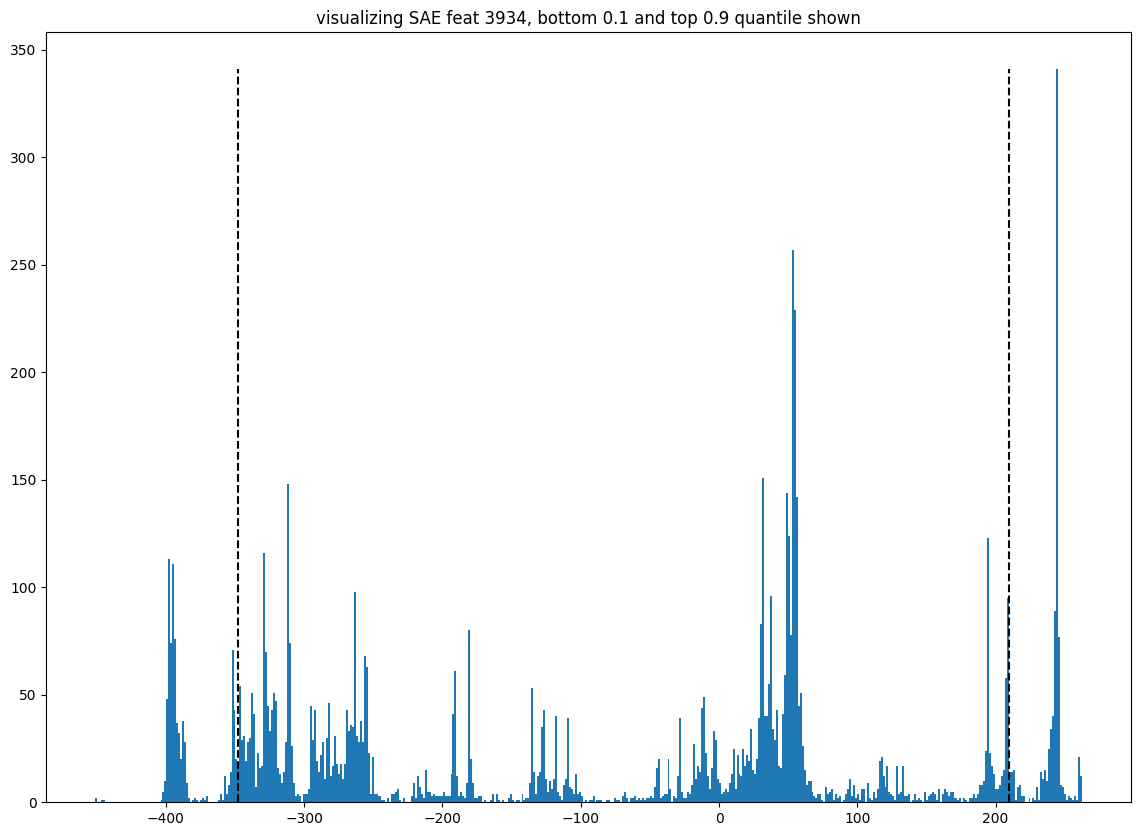

In [414]:
N = 0.1
high_act_filter = torch.quantile(sae_data_pre_acts[:, sae_feat_of_interest], 1 - N)
low_act_filter = torch.quantile(sae_data_pre_acts[:, sae_feat_of_interest], N)

fig, ax = plt.subplots(1,1,figsize=(14,10))
bin_ret = ax.hist(sae_data_pre_acts[:, sae_feat_of_interest].cpu().numpy(), bins=500)
max_bin_val = bin_ret[0].max()

ax.plot([high_act_filter.cpu().numpy() for _ in range(2)], [0, max_bin_val], linestyle="dashed", color="black")
ax.plot([low_act_filter.cpu().numpy() for _ in range(2)], [0, max_bin_val], linestyle="dashed", color="black")

# ax.plot(
ax.set_title(f"visualizing SAE feat {sae_feat_of_interest}, bottom {N} and top {1 - N} quantile shown")
plt.show()

In [415]:
print(f"Analyzing {sae_feat_of_interest}")
high_acts_seqs_idx = torch.argwhere(sae_data_pre_acts[:, sae_feat_of_interest] >= torch.quantile(sae_data_pre_acts[:, sae_feat_of_interest], 1-N)).squeeze()
# low_acts_seqs_idx = torch.argwhere(sae_data_pre_acts[:, sae_feat_of_interest] <= torch.quantile(sae_data_pre_acts[:, sae_feat_of_interest], N)).squeeze()
low_acts_seqs_idx = torch.argwhere(sae_data_pre_acts[:, sae_feat_of_interest] <= 0).squeeze()

Analyzing 3934


In [416]:
def calc_shannon_entropy(seq_data: Float[Tensor, "batch seq_len"]):
    seq_data = seq_data.long()
    one_hot_seq_data = F.one_hot(seq_data, num_classes=len(aa_to_toks_map.keys()))
    one_hot_seq_data_counts = one_hot_seq_data.sum(dim=0)
    one_hot_seq_data_freqs = one_hot_seq_data_counts / one_hot_seq_data_counts.sum(dim=-1, keepdim=True) 
    shannon_entropies = torch.nan_to_num(-one_hot_seq_data_freqs * torch.log(one_hot_seq_data_freqs), nan=0).sum(dim=-1)

    return shannon_entropies, one_hot_seq_data_freqs

In [417]:
high_act_shannon_entropies, high_act_freqs = calc_shannon_entropy(train_sae_seqs[high_acts_seqs_idx, :])
low_act_shannon_entropies, low_act_freqs = calc_shannon_entropy(train_sae_seqs[low_acts_seqs_idx, :])
general_shannon_entropies, general_freqs = calc_shannon_entropy(train_sae_seqs)

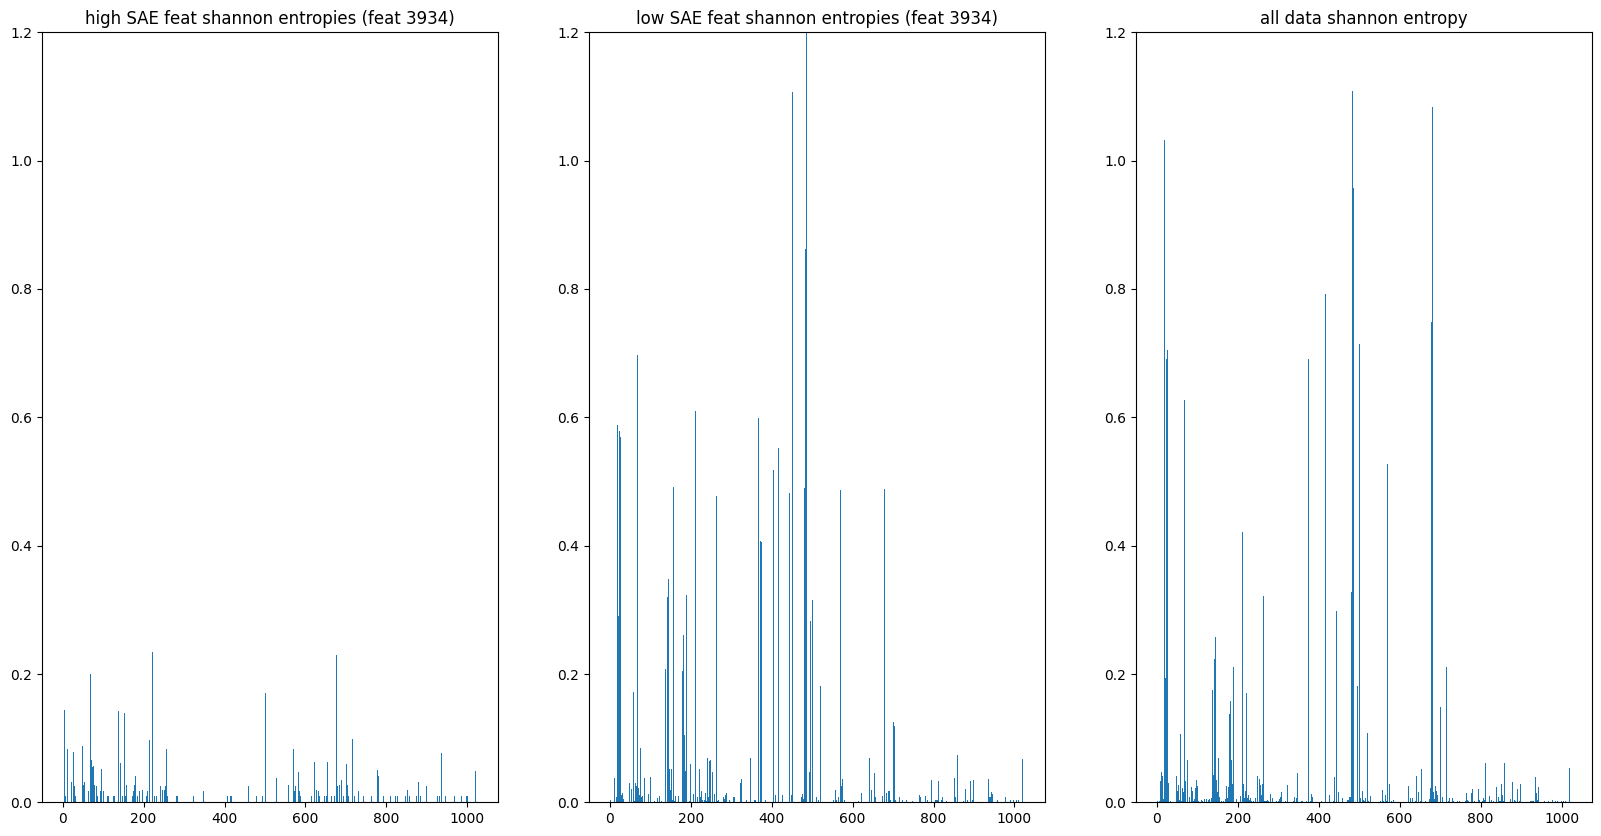

In [418]:
fig, ax = plt.subplots(1,3,figsize=(20,10))
for i,i_title in enumerate([f"high SAE feat shannon entropies (feat {sae_feat_of_interest})",f"low SAE feat shannon entropies (feat {sae_feat_of_interest})","all data shannon entropy"]):
    ax[i].set_title(i_title)

for i, i_data in enumerate([high_act_shannon_entropies, low_act_shannon_entropies, general_shannon_entropies]):
    ax[i].bar(list(range(i_data.shape[0])), i_data.cpu().numpy())
    ax[i].set_ylim([0,1.2])
plt.show()

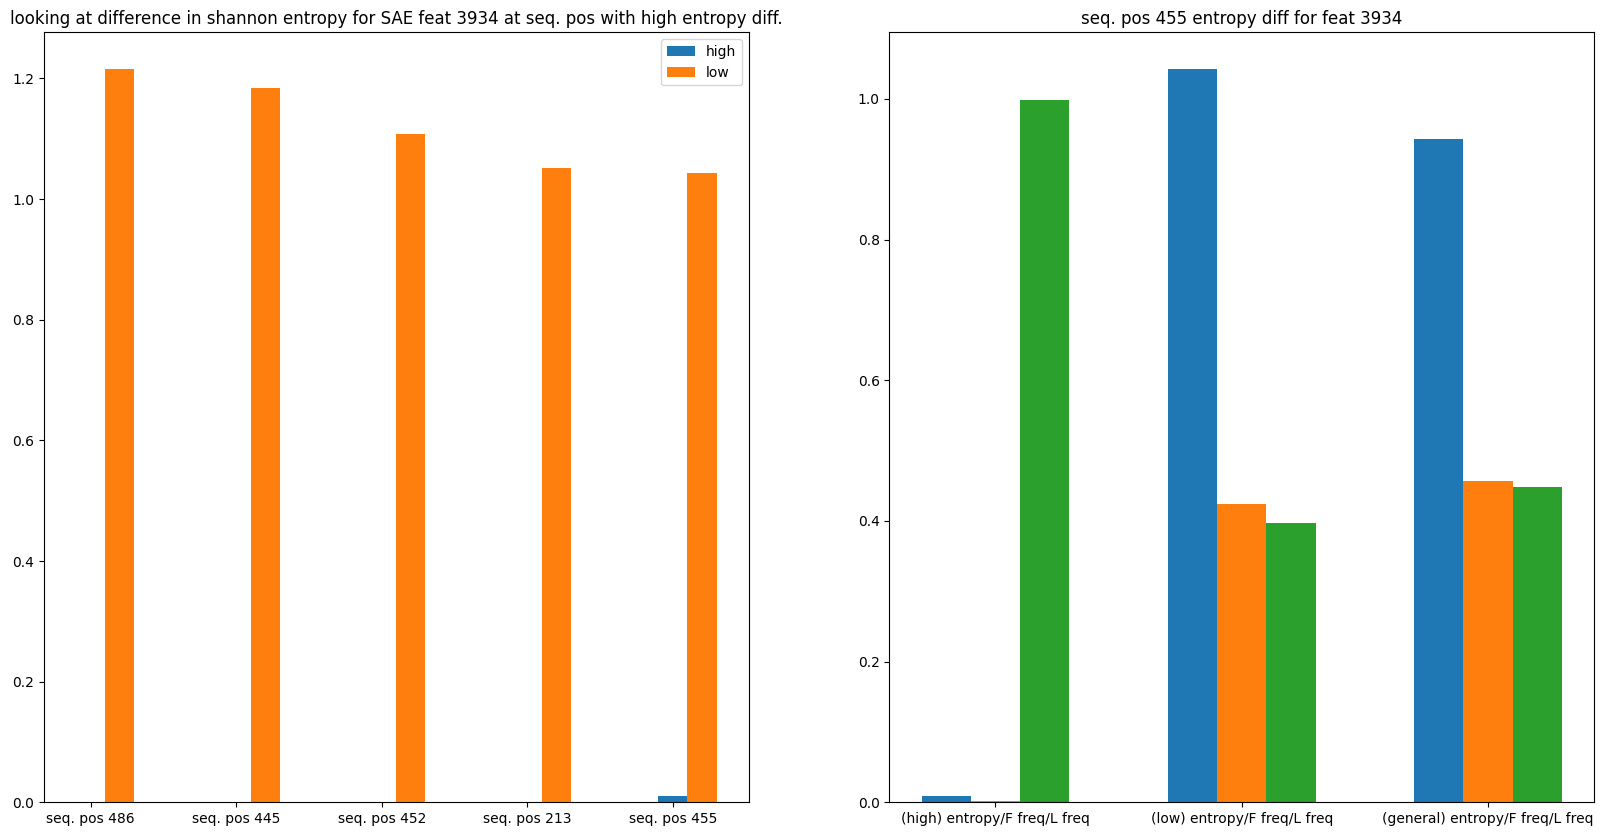

In [419]:
_, max_diffs_inds = (high_act_shannon_entropies - low_act_shannon_entropies).abs().topk(k=5)
max_diffs_inds = max_diffs_inds.cpu().numpy()
fig, ax = plt.subplots(1,2,figsize=(20,10))
ax[0].set_title(f"looking at difference in shannon entropy for SAE feat {sae_feat_of_interest} at seq. pos with high entropy diff.")
for i,s in enumerate([high_act_shannon_entropies, low_act_shannon_entropies]):
    label = "high" if i == 0 else "low"
    ax[0].bar(np.arange(5)+i*0.2, s.cpu().numpy()[max_diffs_inds], label=label, width=0.2)
ax[0].set_xticks(list(range(5)))
ax[0].set_xticklabels([f"seq. pos {x}" for x in max_diffs_inds])
ax[0].legend()
ax[1].set_title(f"seq. pos 455 entropy diff for feat {sae_feat_of_interest}")
ax[1].bar(list(range(3)), [x.cpu().numpy()[455] for x in [high_act_shannon_entropies, low_act_shannon_entropies, general_shannon_entropies]], width=0.2)
f_tok_idx = aa_to_toks_map_rev["F"]
l_tok_idx = aa_to_toks_map_rev["L"]
ax[1].bar(np.arange(3) + 0.2, [x.cpu().numpy()[455][f_tok_idx] for x in [high_act_freqs, low_act_freqs, general_freqs]], width=0.2)
ax[1].bar(np.arange(3) + 0.4, [x.cpu().numpy()[455][l_tok_idx] for x in [high_act_freqs, low_act_freqs, general_freqs]], width=0.2)
ax[1].set_xticks(np.arange(3) + 0.2)
ax[1].set_xticklabels([f"({s}) entropy/F freq/L freq" for s in ["high", "low", "general"]])
plt.show()

# Examining coefficients $f_j(x_i)$ of each argsorted features $d_j$ shown above

### Ideally, the coefficients $f_j(x_i^{\text{HIGH fit}})$ of the high-fitness seq. should be large on the features corr. w/ high fitness. Similarly, the coefficients $f_j(x_i^{\text{LOW fit}})$ of the low-fitness seq. should be large on the features corr. w/ low fitness (this is the 2nd row)
### Further, the high-fitness coefficients should NOT be active on the low-fit features and vice versa (this is the 3rd row)

In [ ]:
high_fitness_acts = sae_data_activations[new_idx, :]
low_fitness_acts = sae_data_activations[orig_idx, :]

In [ ]:
_, _, high_fitness_sae_coefs, high_fit_recon = jumprelu_sae.forward(high_fitness_acts[:, None, :] * MAGNIFICATION_SIZE) #[batch, 1, d_sae], 1 for the n_inst which will be removed
_, _, low_fitness_sae_coefs, low_fit_recon = jumprelu_sae.forward(low_fitness_acts[:, None, :] * MAGNIFICATION_SIZE) #[batch, 1, d_sae], 1 for the n_inst which will be removed

mean_high_fit_sae_coefs = high_fitness_sae_coefs.mean(dim=0)[0] / MAGNIFICATION_SIZE
mean_low_fit_sae_coefs = low_fitness_sae_coefs.mean(dim=0)[0] / MAGNIFICATION_SIZE

In [ ]:
sae_botk_vals, sae_botk_inds = (mean_high_fit_sae_coefs - mean_low_fit_sae_coefs).topk(k=50, largest=False)
disp_sae_botk_inds = sae_botk_inds.cpu().numpy()

sae_topk_vals, sae_topk_inds = (mean_high_fit_sae_coefs - mean_low_fit_sae_coefs).topk(k=50, largest=True)
disp_sae_topk_inds = sae_topk_inds.cpu().numpy()

disp_hf_sae_coefs = mean_high_fit_sae_coefs.cpu().numpy()
disp_lf_sae_coefs = mean_low_fit_sae_coefs.cpu().numpy()

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(14,10))
fig.suptitle("Lowest/Largest diff. in SAE activations")
ax[0,0].bar(list(range(disp_sae_botk_inds.shape[0])), disp_hf_sae_coefs[disp_sae_botk_inds], color="green", linewidth=10)
ax[0,1].bar(list(range(disp_sae_botk_inds.shape[0])), disp_lf_sae_coefs[disp_sae_botk_inds], color="red", linewidth=10)
ax[0,0].set_title("With L455F mut")
ax[0,1].set_title("Original seq.")

ax[1,0].bar(list(range(disp_sae_topk_inds.shape[0])), disp_hf_sae_coefs[disp_sae_topk_inds], color="green", linewidth=10)
ax[1,1].bar(list(range(disp_sae_topk_inds.shape[0])), disp_lf_sae_coefs[disp_sae_topk_inds], color="red", linewidth=10)
ax[1,0].set_title("With L455F mut")
ax[1,1].set_title("Original seq.")
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.set_title("feature scores of regressor high-dimensional features (from SAE) with fitness decoding column", fontsize=16)
ax.bar(list(range(d_sae)), sae_feature_scores[sae_feature_score_sorted_indices], alpha=0.3)
ax.bar(disp_sae_botk_inds, sae_feature_scores[sae_feature_score_sorted_indices[disp_sae_botk_inds]], color="red")
ax.bar(disp_sae_topk_inds, sae_feature_scores[sae_feature_score_sorted_indices[disp_sae_topk_inds]], color="green")
ax.plot([0,d_sae], [sae_quantile_95, sae_quantile_95], color="green", label="high fitness corr.", linestyle="dashed")
ax.plot([0,d_sae], [sae_quantile_05, sae_quantile_05], color="red", label="low fitness corr.", linestyle="dashed")
ax.legend()

ax.set_xlabel("features (argsorted by score)", fontsize=16)
ax.set_ylabel("score (high = high fitness corr., low = low fitness corr.)", fontsize=16)
plt.show()